# 17 - FQAOA circuit with advanced circuit parameterizations

This notebook describes how to apply the annealing and Fourier parameter classes included in OpenQAOA to FQAOA frame work.

In [1]:
%matplotlib notebook
%matplotlib inline

# Import the libraries needed to employ the QAOA and FQAOA quantum algorithm using OpenQAOA
from openqaoa import FQAOA
from openqaoa import QAOA

# method to covnert a docplex model to a qubo problem
from openqaoa.problems import PortfolioOptimization
from openqaoa.backends import create_device
from openqaoa.utilities import bitstring_energy

# Import external libraries to present an manipulate the data
import numpy as np
import matplotlib.pyplot as plt

# Indicate the device, this case is a local simulator
device = create_device('local', 'vectorized')

Start by creating an instance of the portfolio optimisation problem, using the `random_instance` method of `the PortfolioOptimisation` class.

In [2]:
# create a problem instance for portfolio optimization
num_assets = 4 # number of assets
budget = 2 # budget constraint value
problem = PortfolioOptimization.random_instance(num_assets=num_assets, budget=budget, penalty=None).qubo

## Quantum Annealing with FQAOA

The framework of Fermionic QAOA (FQAOA) covers the Quantum Annealing (QA) framework [[1]](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071). In this note, we demonstrate that QA with FQAOA works for constrained combinatorial optimisation problems in practice and compare its performance with QA with conventional QAOA [[2]](https://arxiv.org/pdf/quant-ph/0001106).

### FQAOA Ansatz for QA
FQAOA supports a discretized form of quantum annealing.
Quantum annealing starts with a mixer Hamiltonian ground state and gradually evolves to a cost Hamiltonian ground state.
If the transformation can be performed slowly to infinity, it is guaranteed to reach the exact ground state of the cost Hamiltonian.
In practice, the transformation is performed over a finite time and we want to prepare the ground state with some high probability.

The approximated ground state obtained by QA are as follows:
$$|\psi(T)\rangle = {\cal T}\exp\left\{ -i\int_0^T \left[\left(1-\frac{t}{T}\right)\hat{\cal H}_M+\frac{t}{T}\hat{\cal H}_C\right] dt\right\}\hat{U}_{\rm init}|{\rm vac}\rangle,$$
where the cost $\hat{\cal H}_C$ and mixer $\hat{\cal H}_M$ Hamiltonians, and initial state preparation unitary $\hat{U}_{\rm init}$ are given in the notebook [`16 - Fermionic QAOA (FQAOA)`](https://github.com/tech-sketch/openqaoa/blob/yoshioka1128/dev_clean_fqaoa/examples/16_FQAOA_examples.ipynb). $T$ is annealing time and $\cal T$ is time ordering product for $t$.

The $|\psi(T)\rangle$ is approximated in the following form for calculation in quantum circuits [1, 2]:
$$|\psi(T)\rangle\sim|\psi_p({\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)})\rangle 
= \left[\prod_{j=1}^pU(\hat{\cal H}_M,\beta_j^{(0)}){U}(\hat{\cal H}_C,\gamma_j^{(0)})\right]\hat{U}_{\rm init}|{\rm vac}\rangle,$$
with
\begin{eqnarray}
  \gamma_j^{(0)} &=& \frac{2j-1}{2p}\Delta t, \\
  \beta_j^{(0)}  &=& \left(1-\frac{2j-1}{2p}\right)\Delta t,
\end{eqnarray}
where $\Delta t$ is the unit of discretized annealing time, as $T=p\Delta t$.

In the FQAOA ansatz, the following constraints can be imposed on any integer $M$ smaller than the number of qubits $N$ as:
$$\sum_{i=1}^{N} \hat{n}_i|\psi_p({\boldsymbol \gamma^{(0)}}, {\boldsymbol \beta}^{(0)})\rangle = M|\psi_p({\boldsymbol \gamma^{(0)}}, {\boldsymbol \beta}^{(0)})\rangle,$$
where $\hat{n}_i = \hat{c}^\dagger_i\hat{c}_i$ is number operator and $\hat{c}_i^\dagger (\hat{c}_i)$ is creation (annihilation) operator of fermion at $i$-th site.

The FQAOA ansatz is also improved from $|\psi_p({\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)})\rangle$ by setting ${\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)}$ as initial parameters and running FQAOA. Thus, the performance of the FQAOA framework is guaranteed by QA.

### Running QA using FQAOA Ansatz

In [3]:
# QA using FQAOA
fqaoa_cost_list = []
fqaoa_ip_values = range(1, 11)
fqaoa_dt = 0.2

for ip in fqaoa_ip_values:
    fqaoa = FQAOA(device)
    fqaoa.set_circuit_properties(p=ip, param_type='annealing', init_type='ramp', annealing_time=fqaoa_dt*ip)
    fqaoa.set_classical_optimizer(maxiter=0)
    fqaoa.compile(problem = problem, n_fermions = budget)
    fqaoa.optimize()
    fqaoa_cost_list.append(fqaoa.result.optimized['cost'])

### Running QA using QAOA Ansatz

In [4]:
# QA using QAOA
qaoa_cost_list = []
qaoa_ip_values = range(1, 101)
qaoa_dt = 0.02

for ip in qaoa_ip_values:
    qaoa = QAOA(device)
    qaoa.set_circuit_properties(p=ip, param_type='annealing', init_type='ramp', annealing_time=qaoa_dt*ip)
    qaoa.set_classical_optimizer(maxiter=0)
    qaoa.compile(problem = problem)
    qaoa.optimize()
    qaoa_cost_list.append(qaoa.result.optimized['cost'])

## Performance Evaluation of QA with FQAOA

To evaluate the performance of FQAOA, we show expectation value of costs. 
We define normalized costs by 
$\Delta C_{\boldsymbol x}/W$ with $\Delta C_{\boldsymbol x} = (C_{\boldsymbol x}-C_{\rm min})$ and $W=(C_{\rm max}-C_{\rm min})$, where $C_{\rm max}$ ($C_{\rm min}$) is maximum (minimum) value of cost under the constraint.

In [5]:
x_in_constraint = []
for i in range(2**num_assets):
    bit = bin(i)[2:].zfill(num_assets)
    cost = bitstring_energy(qaoa.cost_hamil, bit[::-1])
    if bit.count('1') == budget:
        x_in_constraint.append(cost)
max_x, min_x = max(x_in_constraint), min(x_in_constraint)
print('(min C_x, max C_x) = ', '(', min_x, max_x,')')

(min C_x, max C_x) =  ( -1.7800188086068625 0.7095615310972656 )


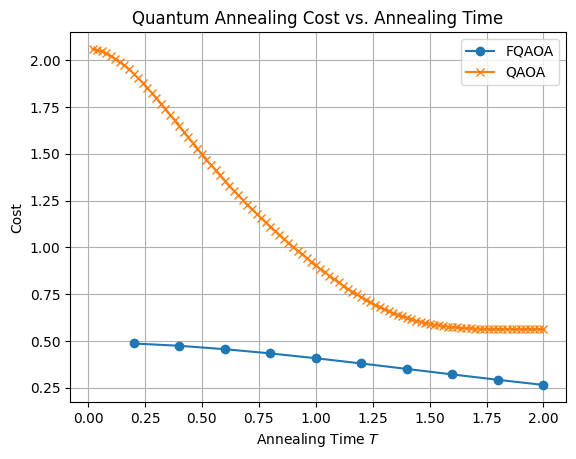

In [6]:
# Plotting costs against annealing time
fqaoa_annealing_times = [ip * fqaoa_dt for ip in fqaoa_ip_values]
fqaoa_cost_list = [(fqaoa_cost_list[i]-min_x)/(max_x-min_x) for i in range(len(fqaoa_cost_list))]
qaoa_annealing_times = [ip * qaoa_dt for ip in qaoa_ip_values]
qaoa_cost_list = [(qaoa_cost_list[i]-min_x)/(max_x-min_x) for i in range(len(qaoa_cost_list))]

# Plotting the results
fqaoa_cost_list
plt.plot(fqaoa_annealing_times, fqaoa_cost_list, marker='o', label='FQAOA')
plt.plot(qaoa_annealing_times, qaoa_cost_list, marker='x', label='QAOA')
plt.xlabel('Annealing Time $T$')
plt.ylabel('Cost')
plt.title(r'Quantum Annealing Cost vs. Annealing Time')
plt.grid(True, which='both')
plt.legend()
plt.show()

## FQAOA with Fourier Parameterization

To appreciate the benefits of the Fourier parameterization, let's compare the case $p=1$ using annealing parameterization with the case $q = 1, p=2$ using `FourierParams`. Here, we are optimising over the same total number of parameters, however the `FourierParams` ought to be capturing features of a more expressive circuit. 

Details of the Fourier parameterization are given in Ref [[3]]((https://journals.aps.org/prx/pdf/10.1103/PhysRevX.10.021067)) and in the Notebook [`05 - QAOA circuit with advanced circuit parameterizations`](https://github.com/entropicalabs/openqaoa/blob/dev/examples/05_advanced_parameterization.ipynb).

### Fourier Parameterization

In [7]:
p_fourier = 3
q = 1

fq_fourier = FQAOA()
fq_fourier.set_circuit_properties(p=p_fourier, param_type='fourier', init_type='ramp', q=q)
fq_fourier.compile(problem = problem, n_fermions=budget)
fq_fourier.optimize()

### Annealing Parameterization

In [8]:
p_annealing = 1

fq_annealing = FQAOA()
fq_annealing.set_circuit_properties(p=p_annealing, param_type='annealing', init_type='ramp')
fq_annealing.compile(problem = problem, n_fermions=budget)
fq_annealing.optimize()

## Performance Evaluation of FQAOA with Fourier Parameterization

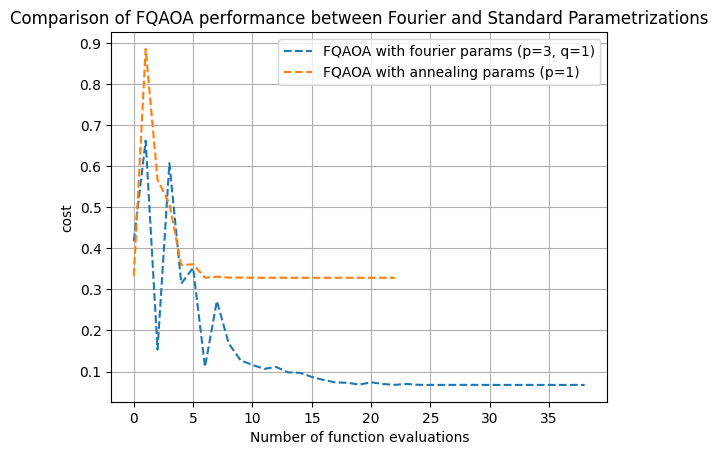

In [11]:
labels = [f'FQAOA with fourier params (p={p_fourier}, q={q})',
          f'FQAOA with annealing params (p={p_annealing})',]

for i, fqaoa in enumerate([fq_fourier, fq_annealing]):
    cost = fqaoa.result.intermediate['cost']
    cost = [(cost[i]-min_x)/(max_x-min_x) for i in range(len(cost))]
    plt.plot(cost, label=labels[i], ls='--')

plt.xlabel('Number of function evaluations')
plt.ylabel('cost')
plt.grid(True)
plt.legend()
plt.title('Comparison of FQAOA performance between Fourier and Annealing Parameterizations')
plt.show()

# References
[1] T. Yoshioka, K. Sasada, Y. Nakano, and K. Fujii, [Phys. Rev. Research 5, 023071 (2023).](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071), [arXiv:2301.10756 [quant-ph]](https://arxiv.org/pdf/2301.10756).\
[2] E. Farhi, J. Goldston, S. Gutmann, and M. Sipser, [arXiv:quant-ph/0001106](https://arxiv.org/pdf/quant-ph/0001106).\
[3] L. Zhou, S. Wang, S. Choi, H. Pichler, and M. D. Lukin, [Phys. Rev. X 10, 021067 (2020).](https://journals.aps.org/prx/pdf/10.1103/PhysRevX.10.021067), [arXiv:1812.01041v2 [quant-ph]](https://arxiv.org/pdf/1812.01041).